In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min';Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

In [2]:
# #####
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_nowarmbubble.nc') #***
# #####
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_noopenBCs.nc') #***

In [3]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [5]:
# #MAKING W HORIZONTAL AVERAGES EVERYWHERE
# def match_xlim_from_axes(axes):
#     """Set consistent x-limits for all axes based on the plotted data."""
#     all_xdata = []
#     for ax in axes:
#         for line in ax.lines:
#             all_xdata.extend(line.get_xdata())
    
#     if all_xdata:
#         xmin = min(all_xdata)
#         xmax = max(all_xdata)
#         for ax in axes:
#             ax.set_xlim(xmin, xmax)
            
# def MakeWPlots(data):
#     times = data['time']
#     time_indices = range(1, len(times)-1, 15)
    
#     n_plots = len(time_indices)
#     ncols = 5
#     nrows = int(np.ceil(n_plots / ncols))
    
#     fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
#     axes = axes.flatten()
    
#     for i, t in enumerate(time_indices):
#         if t % 20 == 0: print(t)
        
#         out = data['winterp'].isel(time=t).mean(dim=('xh', 'yh'))
#         axes[i].plot(out, data['zh'])
#         axes[i].set_title(f"t = {t}")
#         apply_scientific_notation([axes[i]])

#     match_xlim_from_axes(axes)

#     # Optional: hide unused subplots
#     # for j in range(i + 1, len(axes)):
#     #     axes[j].axis('off')

#     fig.suptitle('W Profiles')
#     plt.tight_layout()
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# MakeWPlots(data)
# # ######
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_nowarmbubble.nc') #***
# MakeWPlots(data)
# ######
# # dir2='/home/air673/koa_scratch/'
# # data=xr.open_dataset(dir2+'cm1out_noopenBCs.nc') #***
# # MakeWPlots(data)

In [6]:
# def MakeWPlots_CU(data):
#     times = data['time']
#     time_indices = range(1, len(times)-1, 15)
    
#     n_plots = len(time_indices)
#     ncols = 5
#     nrows = int(np.ceil(n_plots / ncols))
    
#     fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
#     axes = axes.flatten()
    
#     for i, t in enumerate(time_indices):
#         w = data['winterp'].isel(time=t)
#         qcqi = data['qc'].isel(time=t) + data['qi'].isel(time=t)
#         mask = (w > 0.5) & (qcqi >= 1e-6)
        
#         w_masked = w.where(mask)
#         out = w_masked.mean(dim=('xh', 'yh'))
    
#         axes[i].plot(out, data['zh'])
#         axes[i].set_title(f"t = {t}")
#         apply_scientific_notation([axes[i]])

#     # match_xlim_from_axes(axes)

#     # Optional: hide unused subplots
#     # for j in range(i + 1, len(axes)):
#     #     axes[j].axis('off')

#     fig.suptitle('W Cloudy Updraft Profiles')
#     plt.tight_layout()
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# MakeWPlots_CU(data)
# ######
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_nowarmbubble.nc') #***
# MakeWPlots_CU(data)
# #####
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_noopenBCs.nc') #***
# MakeWPlots_CU(data)

In [7]:
def MatchAxisLimits(axes, dim='x', buffer_frac=0.05):
    """
    Set consistent limits for either x or y axis based on the plotted data,
    adding a buffer on each end (default 5%).
    
    Parameters:
        axes (list): list of matplotlib Axes objects
        dim (str): 'x' or 'y' to specify which axis limits to match
        buffer_frac (float): fraction of data range to use as buffer on each side
    """
    all_data = []
    for ax in axes:
        for line in ax.lines:
            if dim == 'x':
                all_data.extend(line.get_xdata())
            elif dim == 'y':
                all_data.extend(line.get_ydata())
            else:
                raise ValueError("dim must be 'x' or 'y'")

    if all_data:
        xmin = min(all_data)
        xmax = max(all_data)
        data_range = xmax - xmin
        buffer = data_range * buffer_frac

        for ax in axes:
            if dim == 'x':
                ax.set_xlim(xmin - buffer, xmax + buffer)
            else:
                ax.set_ylim(xmin - buffer, xmax + buffer)


In [8]:
###########################################################################
#MASS FLUX CALCULATIONS

In [9]:
#MAKING VELOCITY MASS FLUX HORIZONTAL AVERAGES EVERYWHERE

            
def MakeVelocityPlots(data,velocity_name):
    times = data['time']
    time_indices = range(1, len(times)-1, 15)
    
    n_plots = len(time_indices)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
    axes = axes.flatten()
    
    for i, t in enumerate(time_indices):
        if t % 20 == 0: print(t)
        velocity = data[velocity_name].isel(time=t);rho = data['rho'].isel(time=t)
        product=rho*velocity
        out = product.mean(dim=('xh', 'yh'))
        axes[i].plot(out, data['zh'])
        axes[i].set_title(f"t = {t}")
        axes[i].axvline(0,color='black',linestyle='dashed')
        apply_scientific_notation([axes[i]])

    MatchAxisLimits(axes,'x')

    # Optional: hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'rho*{velocity_name} Profiles')
    plt.tight_layout()
    

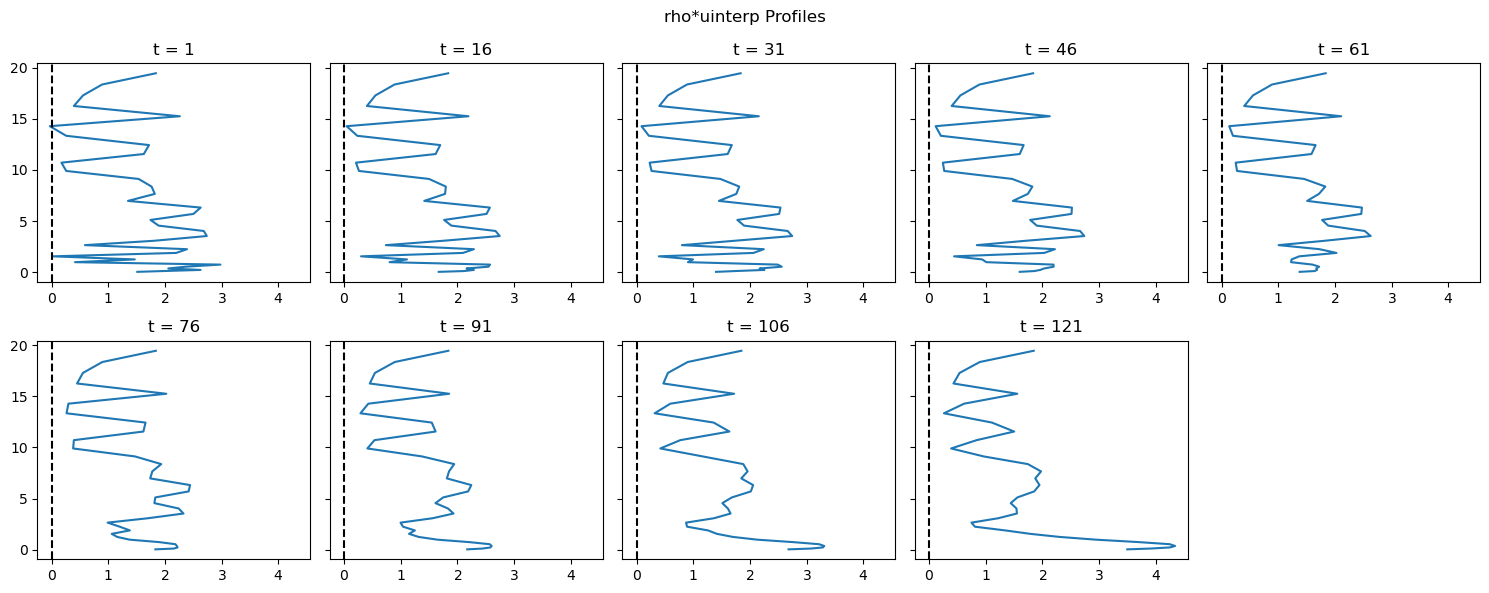

In [220]:
MakeVelocityPlots(data,'uinterp')

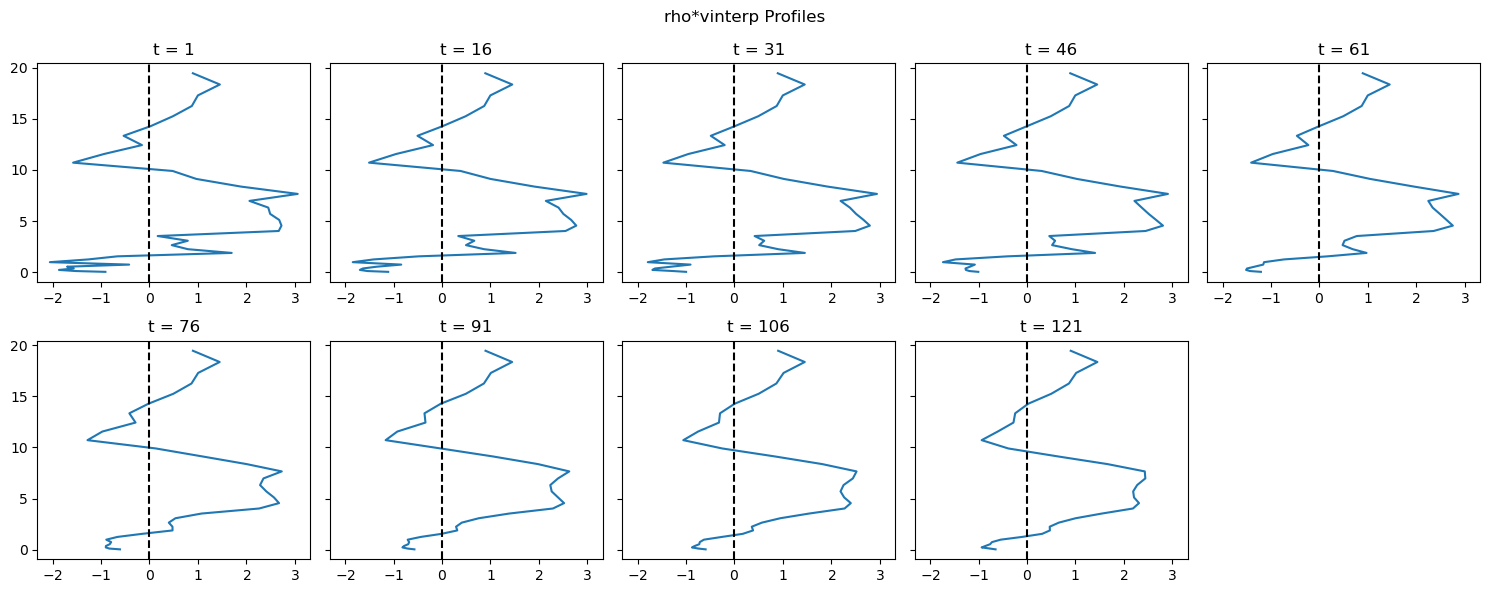

In [221]:
MakeVelocityPlots(data,'vinterp')

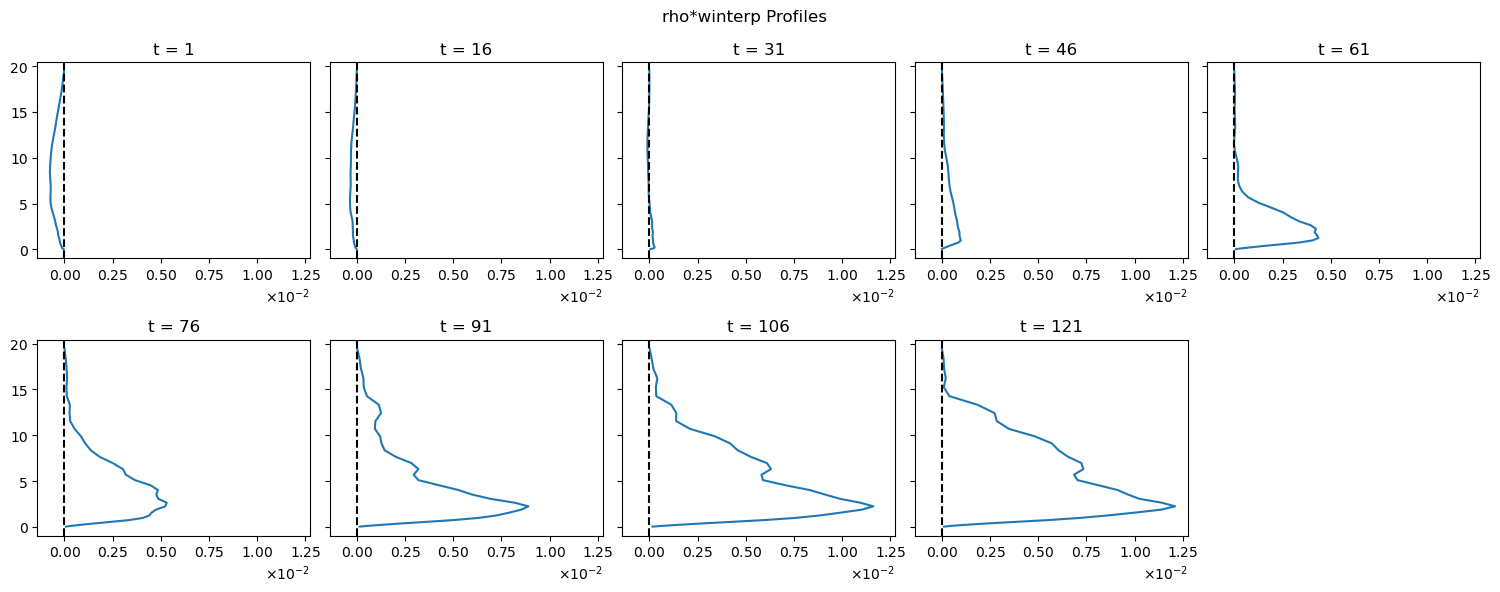

In [222]:
MakeVelocityPlots(data,'winterp')

In [ ]:
###########################################################################
#MASS CONTINUITY SINGLE TIMESTEP

In [ ]:
###########################################################################
#MASS CONTINUITY MULTIPLE TIMESTEPS

In [223]:
def ddt(t1, t2, dt): 
    # _ddt = (t2 - t1) / dt #forward difference
    _ddt = (t2 - t1) / (2*dt) #central difference
    return _ddt


#CALCULATE RHO TENDENCY HORIZONTAL MEANS
def MakeRhoTendencyPlot(data):
    times = data['time']
    time_indices = range(1, len(times)-1, 15)
    
    n_plots = len(time_indices)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
    axes = axes.flatten()
    
    for i, t in enumerate(time_indices):
        if t % 20 == 0: print(t)
    
        t1=data['rho'].isel(time=t-1);t2=data['rho'].isel(time=t+1)
        product2=ddt(t1=t1.data, t2=t2.data, dt=300)
        out = np.mean(product2,axis=(1,2))
        axes[i].plot(out, data['zh'])
        axes[i].set_title(f"t = {t}")
        axes[i].axvline(0,color='black',linestyle='dashed')
        apply_scientific_notation([axes[i]])

    MatchAxisLimits(axes,'x')

    # Optional: hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'drho/dt (forward difference) Profiles')
    plt.tight_layout()
    

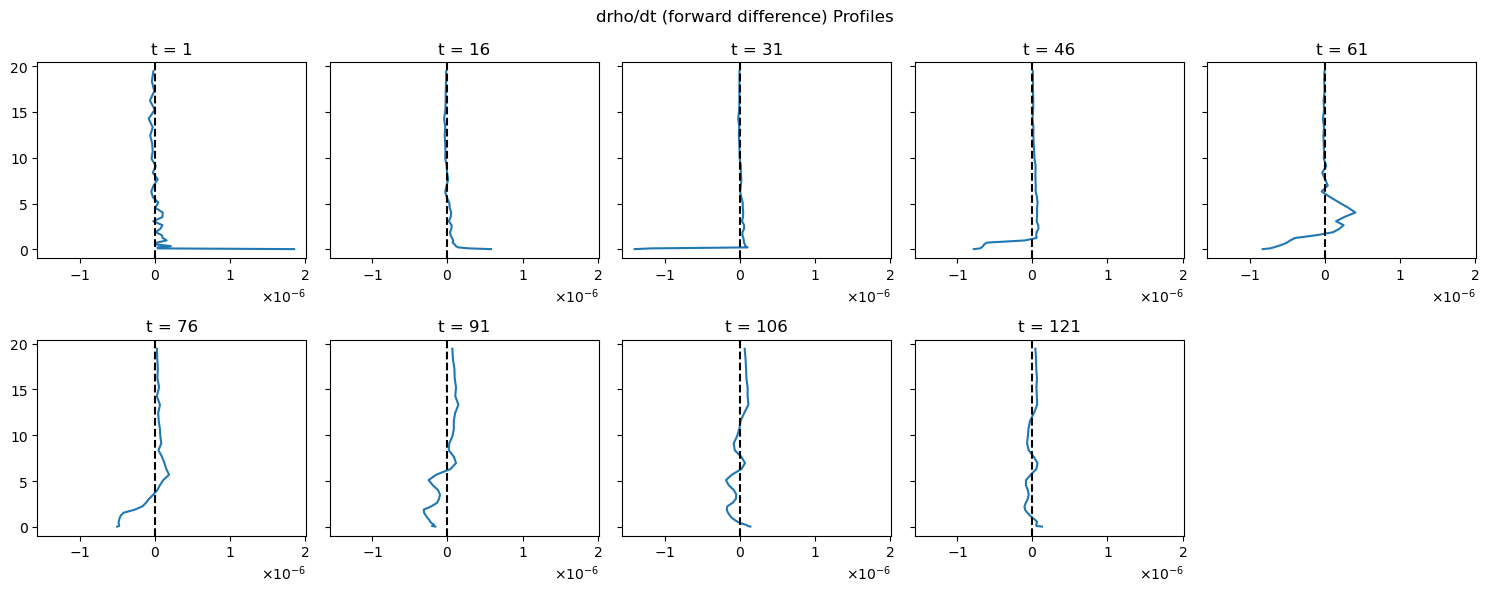

In [224]:
MakeRhoTendencyPlot(data)

In [225]:
#MAKING DERIVATIVES HORIZONTAL MEAN
def MakeVelocityGradientPlots(data,velocity_name,gradient_dim):
    if gradient_dim=='x':
        gradient_function=Ddx_3D
        gradient_name='ddx'
    elif gradient_dim=='y':
        gradient_function=Ddy_3D
        gradient_name='ddy'
    elif gradient_dim=='z':
        gradient_function=Ddz_3DStretch
        gradient_name='ddz'
    times = data['time']
    time_indices = range(1, len(times)-1, 15)
    
    n_plots = len(time_indices)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
    axes = axes.flatten()
    
    for i, t in enumerate(time_indices):
        if t % 20 == 0: print(t)
        velocity = data[velocity_name].isel(time=t);rho = data['rho'].isel(time=t)
        product=rho*velocity
        if gradient_dim!='z':
            product2=gradient_function(product.data,1000)
        elif gradient_dim=='z':
            product2=gradient_function(product.data,data)

        out = np.mean(product2,axis=(1,2))
        axes[i].plot(out, data['zh'])
        axes[i].set_title(f"t = {t}")
        axes[i].axvline(0,color='black',linestyle='dashed')
        apply_scientific_notation([axes[i]])

    MatchAxisLimits(axes,'x')

    # Optional: hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{gradient_name}(rho*{velocity_name}) Profiles')
    plt.tight_layout()
    

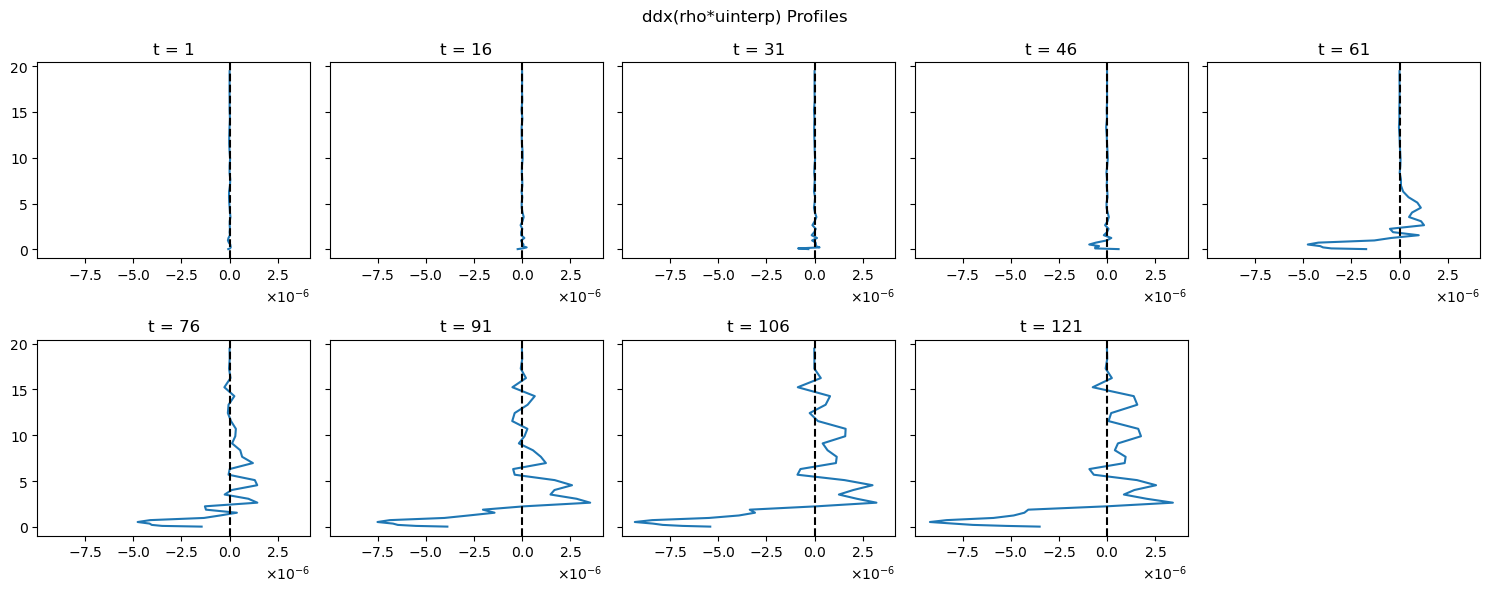

In [226]:
MakeVelocityGradientPlots(data,'uinterp','x')

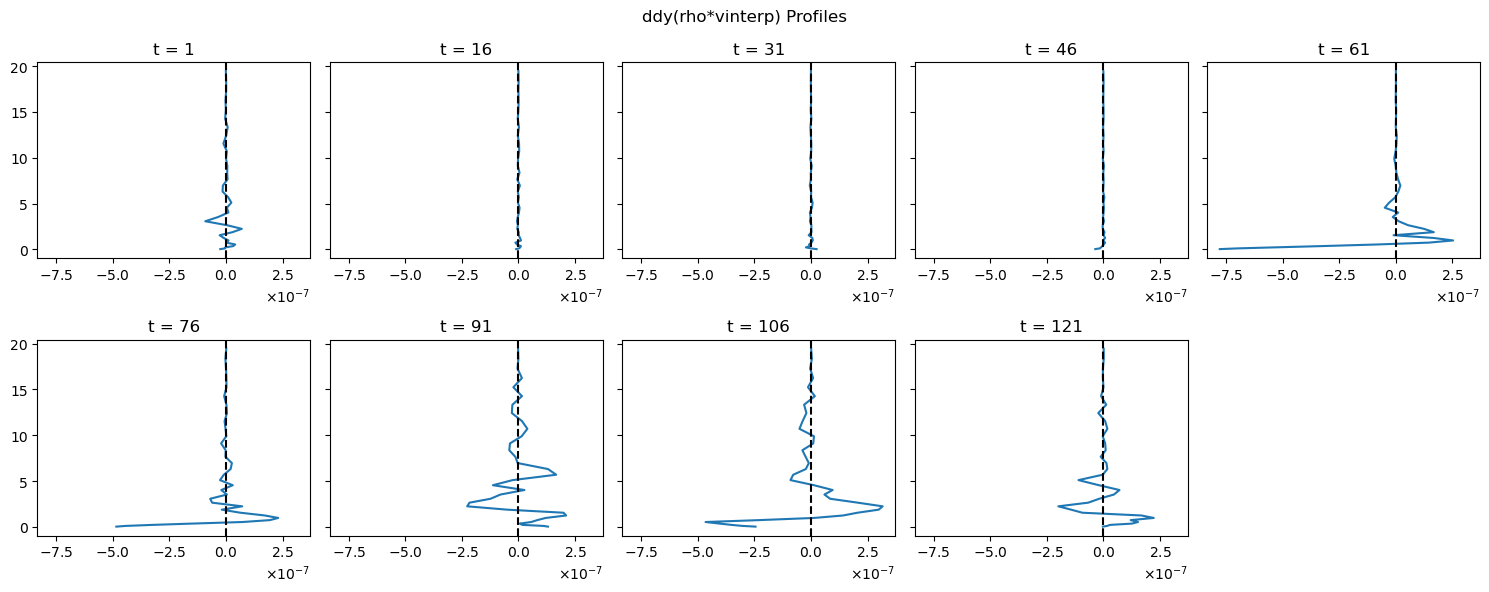

In [227]:
MakeVelocityGradientPlots(data,'vinterp','y')

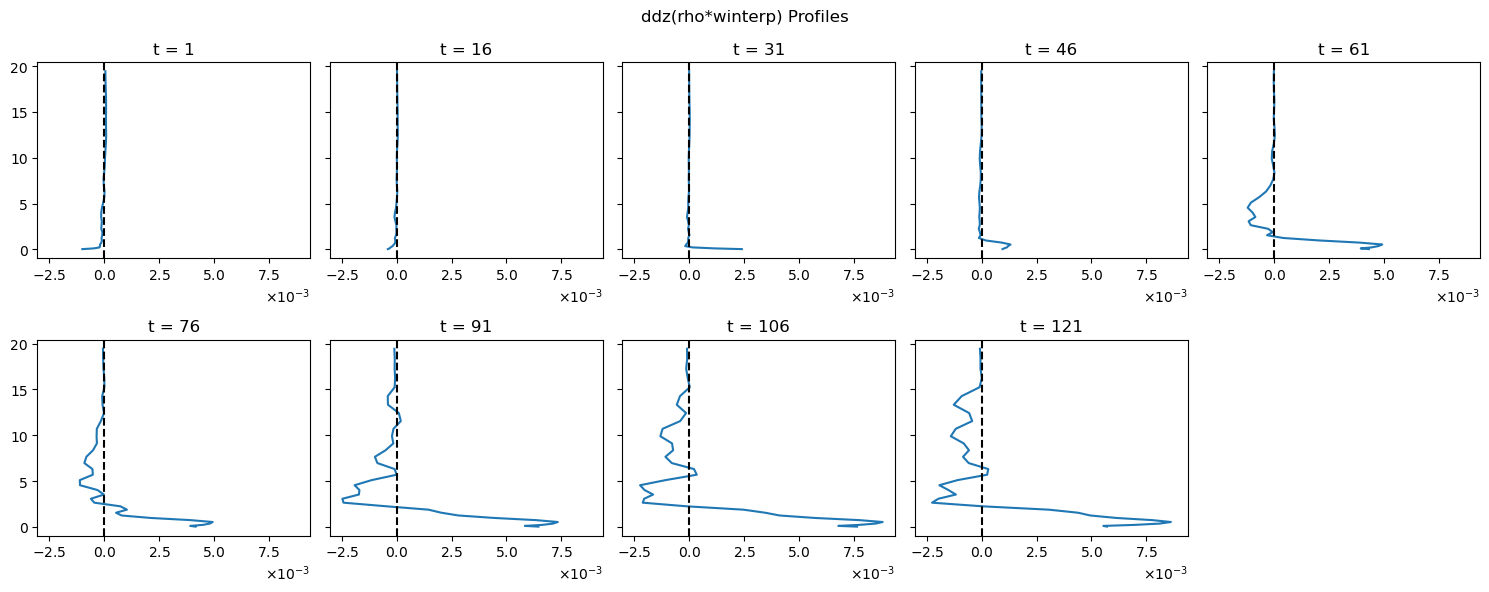

In [228]:
MakeVelocityGradientPlots(data,'winterp','z')

In [235]:
#CALCULATE RHO TENDENCY HORIZONTAL MEANS
def MakeMassContinuityDivergencePlot(data):
    times = data['time']
    time_indices = range(1, len(times)-1, 15)
    
    n_plots = len(time_indices)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
    axes = axes.flatten()
    
    for i, t in enumerate(time_indices):
        if t % 20 == 0: print(t)
        rho=data['rho'].isel(time=t).data
        u = data['uinterp'].isel(time=t).data; v = data['vinterp'].isel(time=t).data; w = data['winterp'].isel(time=t).data
        div1= Ddx_3D(f=rho*u,dx=1000)
        div2= Ddy_3D(f=rho*v,dy=1000)
        div3= Ddz_3DStretch(f=rho*w,data=data)
    
        product2=div1+div2+div3
        out = np.mean(product2,axis=(1,2))
        axes[i].plot(out, data['zh'])
        axes[i].set_title(f"t = {t}")
        axes[i].axvline(0,color='black',linestyle='dashed')
        apply_scientific_notation([axes[i]])

    MatchAxisLimits(axes,'x')

    # Optional: hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    #d(rho*u)/dx+d(rho*v)/dy+d(rho*w)/dz
    fig.suptitle(f'Mass Flux Divergence Term Profiles')
    plt.tight_layout()
    

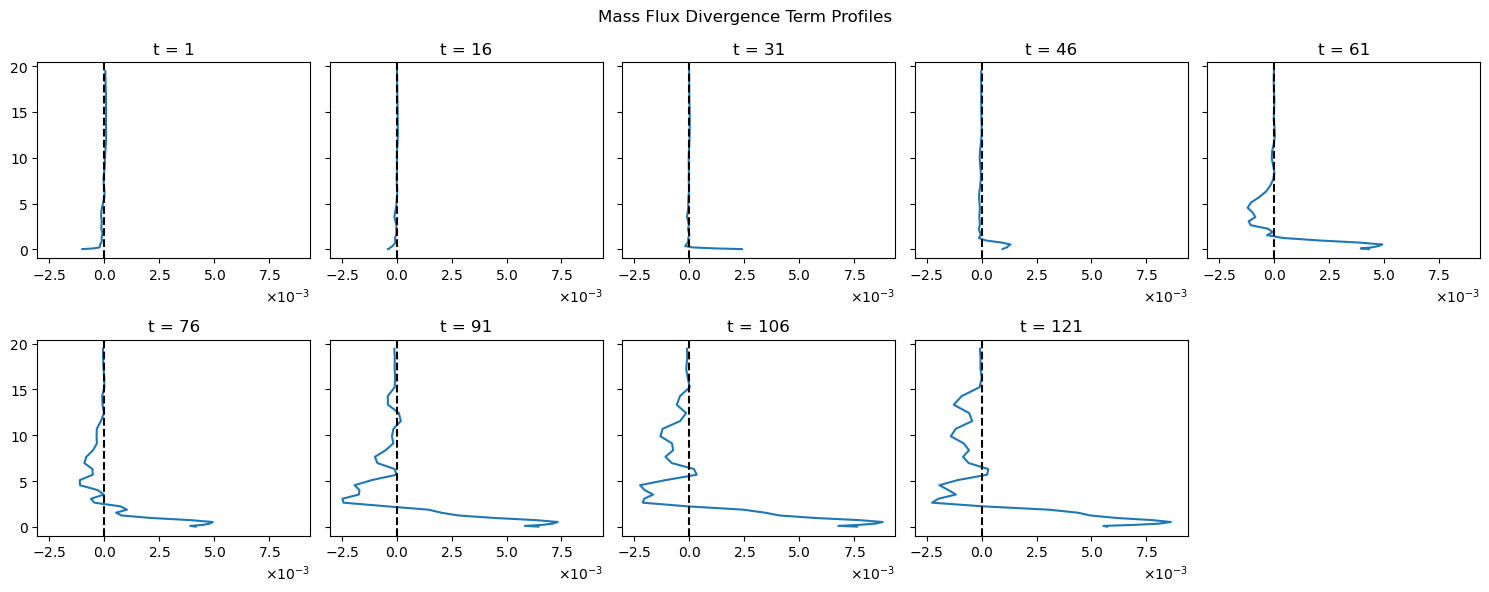

In [236]:
MakeMassContinuityDivergencePlot(data)

In [231]:
def ddt(t1, t2, dt): 
    # _ddt = (t2 - t1) / dt #forward difference
    _ddt = (t2 - t1) / (2*dt) #central difference
    return _ddt


#CALCULATE RHO TENDENCY HORIZONTAL MEANS
def MakeMassContinuityLHSPlot(data):
    times = data['time']
    time_indices = range(1, len(times)-1, 15)
    
    n_plots = len(time_indices)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows), sharey=True)
    axes = axes.flatten()
    
    for i, t in enumerate(time_indices):
        if t % 20 == 0: print(t)

        #RHO TENDENCY
        t1=data['rho'].isel(time=t-1).data;t2=data['rho'].isel(time=t+1).data
        rhotend=ddt(t1=t1, t2=t2, dt=300)

        #DIVERGENCE TERMS
        rho=data['rho'].isel(time=t).data
        u = data['uinterp'].isel(time=t).data; v = data['vinterp'].isel(time=t).data; w = data['winterp'].isel(time=t).data
        div1= Ddx_3D(f=rho*u,dx=1000)
        div2= Ddy_3D(f=rho*v,dy=1000)
        div3= Ddz_3DStretch(f=rho*w,data=data)

        #COMBINING
        product2=rhotend+div1+div2+div3

        #TAKING AVERAGE
        out = np.mean(product2,axis=(1,2))

        #PLOTTING
        axes[i].plot(out, data['zh'])
        axes[i].set_title(f"t = {t}")
        axes[i].axvline(0,color='black',linestyle='dashed')
        apply_scientific_notation([axes[i]])

    MatchAxisLimits(axes,'x')

    # Optional: hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    #d(rho)/dt + d(rho*u)/dx+d(rho*v)/dy+d(rho*w)/dz
    fig.suptitle(f'Mass Continuity LHS Profiles')
    plt.tight_layout()
    

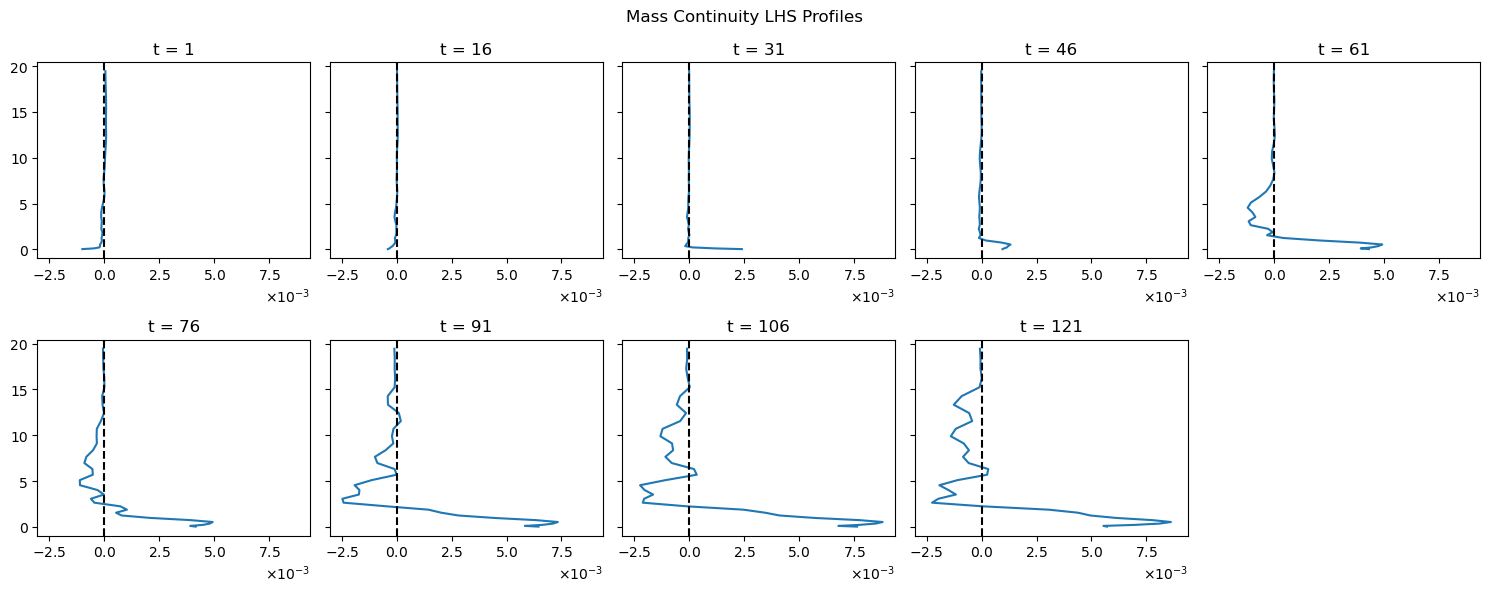

In [232]:
MakeMassContinuityLHSPlot(data)

In [ ]:
def plot_mean_LHS_vs_z(LHS, zh):
    fig, ax = plt.subplots()
    ax.plot(np.mean(LHS, axis=(1, 2)), zh)
    ax.set_title('Continuity LHS Mean (y,x)')
    ax.set_xlabel('LHS')
    ax.set_ylabel('z (km)')
    return fig, ax

def plot_mean_LHS_vs_x(LHS, xh):
    fig, ax = plt.subplots()
    ax.plot(xh, np.mean(LHS, axis=(0, 1)))
    ax.set_title('Continuity LHS Mean (z,y)')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('LHS')
    return fig, ax

def plot_mean_LHS_vs_y(LHS, yh):
    fig, ax = plt.subplots()
    ax.plot(np.mean(LHS, axis=(0, 2)), yh)
    ax.set_title('Continuity LHS Mean (z,x)')
    ax.set_xlabel('LHS')
    ax.set_ylabel('y (km)')
    return fig, ax

def contourf_LHS_xy(LHS, x, y, eps=1e-3):
    out = np.mean(LHS, axis=0)
    out = np.where(np.abs(out) <= eps, np.nan, out)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(x, y, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(contour, ax=ax)
    ax.set_title(f'Continuity LHS (z) Mean\n(White = |val| ≤ {eps})')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    return fig, ax

def contourf_LHS_xz(LHS, x, z, eps=1e-3):
    out = np.mean(LHS, axis=1)
    out = np.where(np.abs(out) <= eps, np.nan, out)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(x, z, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(contour, ax=ax)
    ax.set_title(f'Continuity LHS (y) Mean\n(White = |val| ≤ {eps})')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('z (km)')
    return fig, ax

def contourf_LHS_yz(LHS, y, z, eps=1e-3):
    out = np.mean(LHS, axis=2)
    out = np.where(np.abs(out) <= eps, np.nan, out)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(y, z, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(contour, ax=ax)
    ax.set_title(f'Continuity LHS (x) Mean\n(White = |val| ≤ {eps})')
    ax.set_xlabel('y (km)')
    ax.set_ylabel('z (km)')
    return fig, ax

def ddt(t1, t2, dt): 
    # _ddt = (t2 - t1) / dt #forward difference
    _ddt = (t2 - t1) / (2*dt) #central difference
    return _ddt
    
def TestSingleTime(t):

    #RHO TENDENCY
    t1=data['rho'].isel(time=t-1).data;t2=data['rho'].isel(time=t+1).data
    rhotend=ddt(t1=t1, t2=t2, dt=300)
    
    #DIVERGENCE TERMS
    rho=data['rho'].isel(time=t).data
    u = data['uinterp'].isel(time=t).data; v = data['vinterp'].isel(time=t).data; w = data['winterp'].isel(time=t).data
    div1= Ddx_3D(f=rho*u,dx=1000)
    div2= Ddy_3D(f=rho*v,dy=1000)
    div3= Ddz_3DStretch(f=rho*w,data=data)

    out=rhotend+(div1+div2+div3)
    return out

# t=91
t=int(91*5)
LHS=TestSingleTime(t=t)

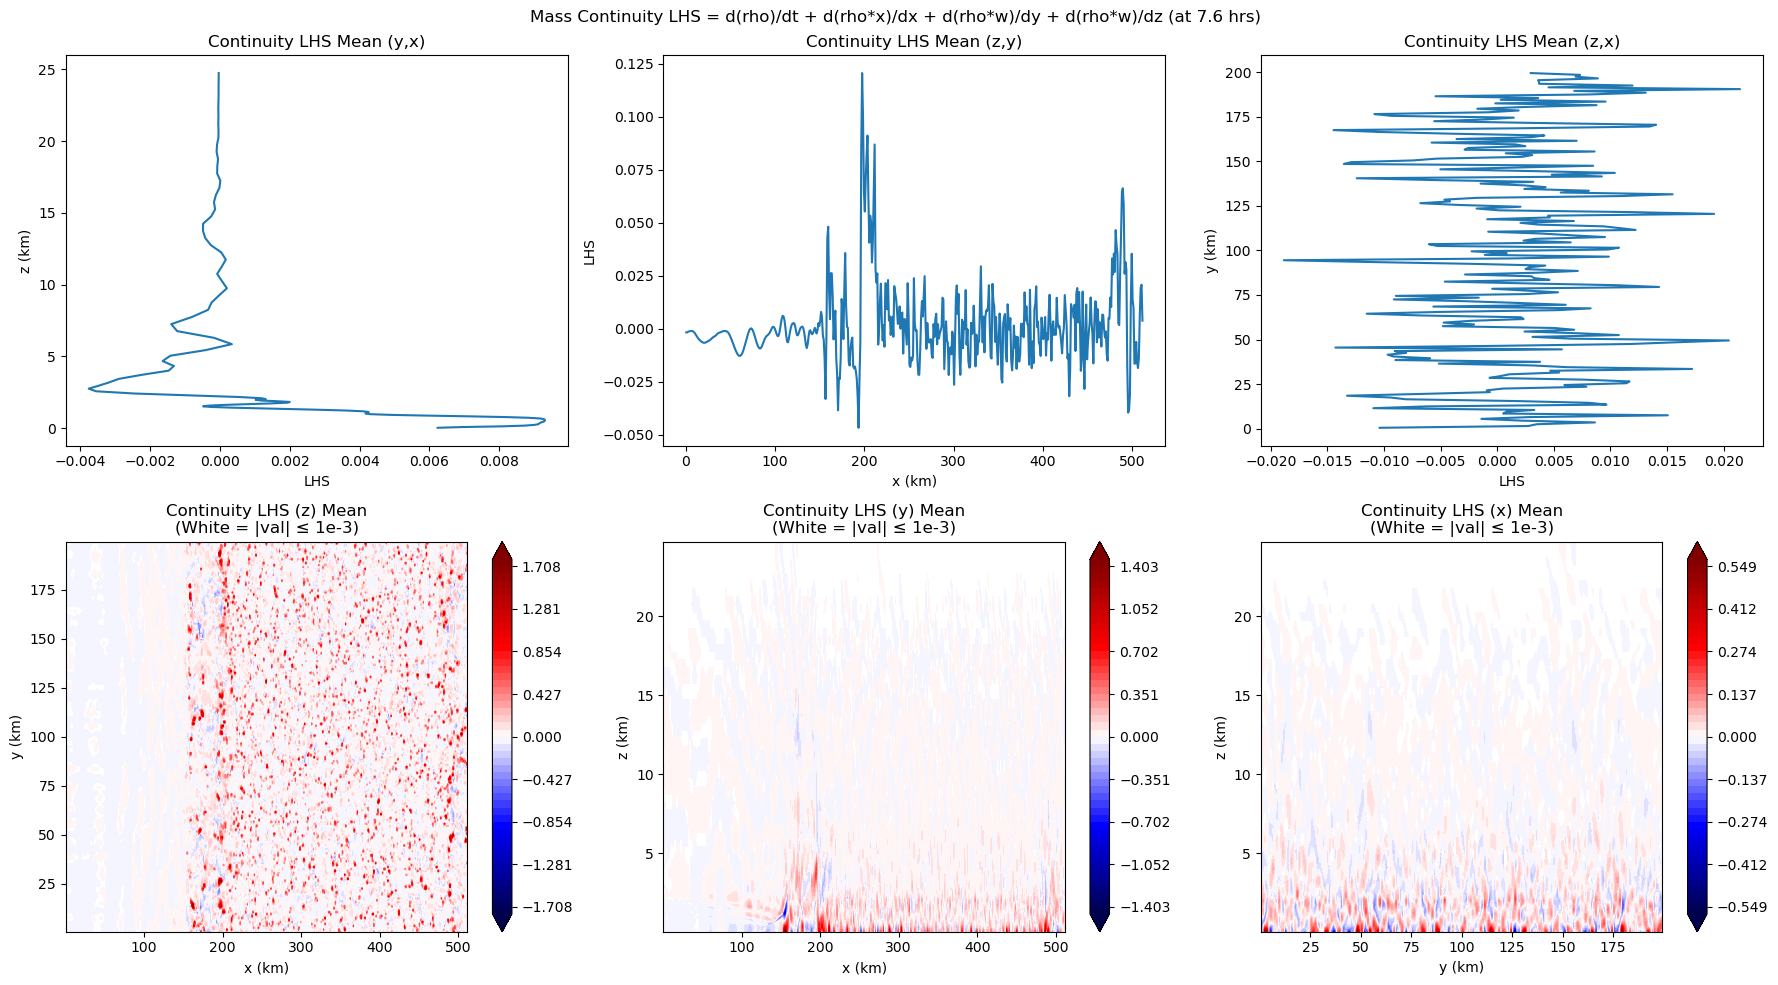

In [351]:
import matplotlib.pyplot as plt
import numpy as np

eps = 1e-3

fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 cols

# --------- Row 1: Line plots ---------
# Plot 1: Mean LHS vs z
axs[0, 0].plot(np.mean(LHS, axis=(1, 2)), data['zh'])
axs[0, 0].set(title='Continuity LHS Mean (y,x)', xlabel='LHS', ylabel='z (km)')

# Plot 2: Mean LHS vs x
axs[0, 1].plot(data['xh'], np.mean(LHS, axis=(0, 1)))
axs[0, 1].set(title='Continuity LHS Mean (z,y)', xlabel='x (km)', ylabel='LHS')

# Plot 3: Mean LHS vs y
axs[0, 2].plot(np.mean(LHS, axis=(0, 2)), data['yh'])
axs[0, 2].set(title='Continuity LHS Mean (z,x)', xlabel='LHS', ylabel='y (km)')

# --------- Row 2: Contour plots ---------
# Prepare contour data function for convenience
def prep_contour(data_array, axis_to_mean, x_vals, y_vals, xlabel, ylabel, ax):
    out = np.mean(data_array, axis=axis_to_mean)
    out = np.where(np.abs(out) <= eps, np.nan, out)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    cont = ax.contourf(x_vals, y_vals, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(cont, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

# Plot 4: Mean over axis=0, contour in (x, y)
prep_contour(LHS, axis_to_mean=0, x_vals=data['xh'], y_vals=data['yh'], xlabel='x (km)', ylabel='y (km)', ax=axs[1, 0])
axs[1, 0].set_title('Continuity LHS (z) Mean\n(White = |val| ≤ 1e-3)')

# Plot 5: Mean over axis=1, contour in (x, z)
prep_contour(LHS, axis_to_mean=1, x_vals=data['xh'], y_vals=data['zh'], xlabel='x (km)', ylabel='z (km)', ax=axs[1, 1])
axs[1, 1].set_title('Continuity LHS (y) Mean\n(White = |val| ≤ 1e-3)')

# Plot 6: Mean over axis=2, contour in (y, z)
prep_contour(LHS, axis_to_mean=2, x_vals=data['yh'], y_vals=data['zh'], xlabel='y (km)', ylabel='z (km)', ax=axs[1, 2])
axs[1, 2].set_title('Continuity LHS (x) Mean\n(White = |val| ≤ 1e-3)')

hrs=np.round(data['time'][t].item()/1e9/60**2,1)
plt.suptitle(f'Mass Continuity LHS = d(rho)/dt + d(rho*x)/dx + d(rho*w)/dy + d(rho*w)/dz (at {hrs} hrs)')
plt.tight_layout()

In [ ]:
########################################################
#CALCULATING AT A SINGLE Z LEVEL

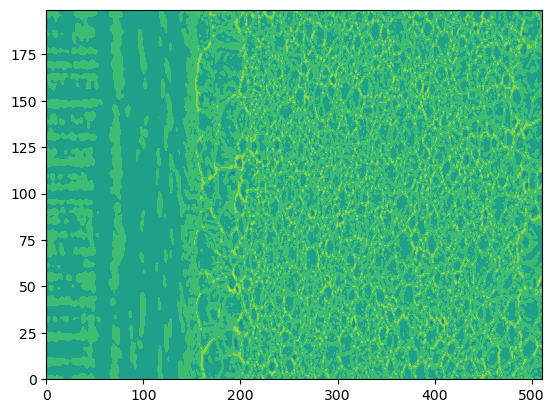

In [9]:
# t=91
t=int(91*5)
z_lev=5
winterp_tz=data['winterp'].isel(time=t,zh=z_lev).data
plt.contourf(winterp_tz) 

In [4]:
def ddt(t1, t2, dt): 
    # _ddt = (t2 - t1) / dt #forward difference
    _ddt = (t2 - t1) / (2*dt) #central difference
    return _ddt

In [5]:

def TestSingleTime(t):

    #RHO TENDENCY
    t1=data['rho'].isel(time=t-1).data;t2=data['rho'].isel(time=t+1).data
    rhotend=ddt(t1=t1, t2=t2, dt=300)
    
    #DIVERGENCE TERMS
    rho=data['rho'].isel(time=t).data
    u = data['uinterp'].isel(time=t).data; v = data['vinterp'].isel(time=t).data; w = data['winterp'].isel(time=t).data
    div1= Ddx_3D(f=rho*u,dx=1000)
    div2= Ddy_3D(f=rho*v,dy=1000)
    div3= Ddz_3DStretch(f=rho*w,data=data)

    out=rhotend+(div1+div2+div3)
    return out

In [10]:
uinterp_t=data['uinterp'].isel(time=t).data
vinterp_t=data['vinterp'].isel(time=t).data
winterp_t=data['winterp'].isel(time=t).data
rho_t=data['winterp'].isel(time=t).data

In [16]:
#TIME MASS FLUX
t1=data['winterp'].isel(time=t-1).data
t2=data['winterp'].isel(time=t+1).data
ddt_rho=ddt(t1,t2,60)

#DDZ (VERTICAL MASS FLUX)
w_massflux_t=rho_t*winterp_t
ddz_rho_w=Ddz_3DStretch(w_massflux_t,data)

#DDY (VERTICAL MASS FLUX)
v_massflux_t=rho_t*vinterp_t
ddy_rho_v=Ddy_3D(v_massflux_t,dy=1000)

#DDX (VERTICAL MASS FLUX)
u_massflux_t=rho_t*uinterp_t
ddx_rho_u=Ddx_3D(u_massflux_t,dx=1000)

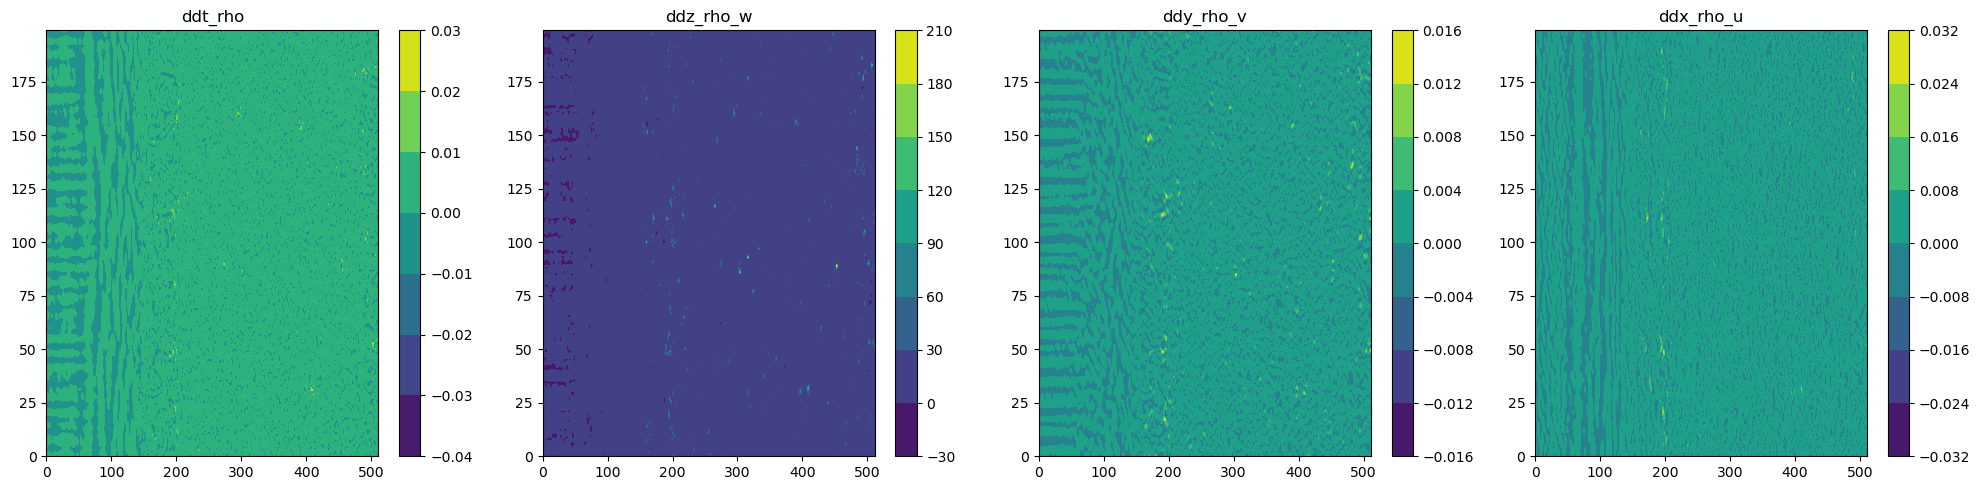

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# Plot 1: ddt_rho at z_lev
cont1 = axs[0].contourf(ddt_rho[z_lev])
fig.colorbar(cont1, ax=axs[0])
axs[0].set_title('ddt_rho')

# Plot 2: ddz_rho_w at z_lev
cont2 = axs[1].contourf(ddz_rho_w[z_lev])
fig.colorbar(cont2, ax=axs[1])
axs[1].set_title('ddz_rho_w')

# Plot 3: ddy_rho_v at z_lev
cont3 = axs[2].contourf(ddy_rho_v[z_lev])
fig.colorbar(cont3, ax=axs[2])
axs[2].set_title('ddy_rho_v')

# Plot 4: ddx_rho_u at z_lev
cont4 = axs[3].contourf(ddx_rho_u[z_lev])
fig.colorbar(cont4, ax=axs[3])
axs[3].set_title('ddx_rho_u')

plt.tight_layout()
plt.show()


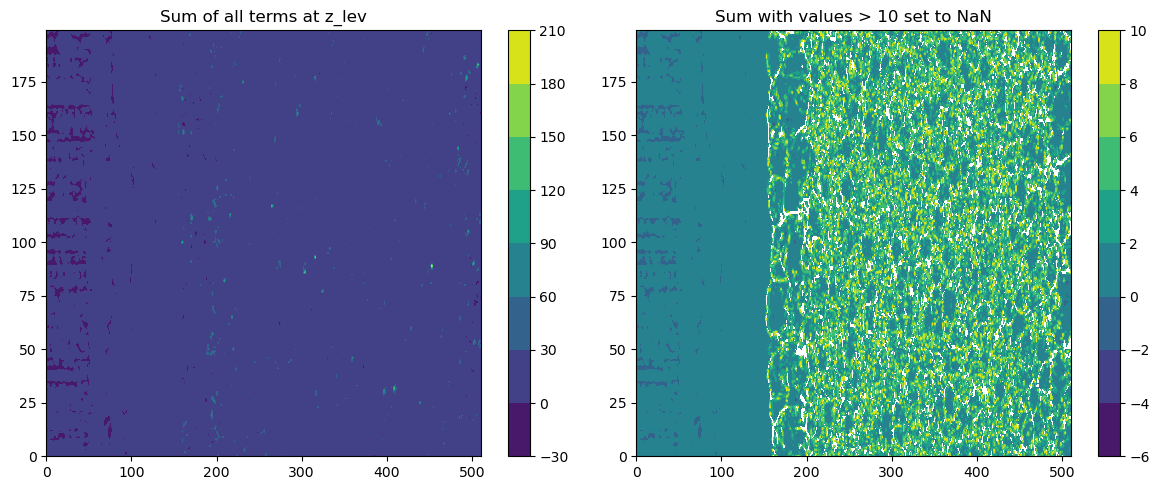

In [43]:
import numpy as np
import matplotlib.pyplot as plt

combined = ddt_rho[z_lev] + ddz_rho_w[z_lev] + ddy_rho_v[z_lev] + ddx_rho_u[z_lev]

mask_num = 10

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: original combined
cont1 = axs[0].contourf(combined)
fig.colorbar(cont1, ax=axs[0])
axs[0].set_title('Sum of all terms at z_lev')

# Plot 2: masked combined (values > mask_num set to NaN)
combined_masked = np.where(combined > mask_num, np.nan, combined)
cont2 = axs[1].contourf(combined_masked)
fig.colorbar(cont2, ax=axs[1])
axs[1].set_title(f'Sum with values > {mask_num} set to NaN')

plt.tight_layout()
plt.show()
